# Classifiers

In this notebook, the [classification](https://en.wikipedia.org/wiki/Statistical_classification) problem is explored through different algorithms (**Support Vector Machines** (SVM) and **Random Forest** (RF)), also known as classifiers. 
The objective is to assess the capabilities of each framework, by comparing their accuracy and computational complexity when applied to small datasets with varying number of features.

The data is directly available from `sklearn`, with the [toy datasets](https://scikit-learn.org/stable/datasets/toy_dataset.html#toy-datasets) being small, simple datasets commonly used for training, testing, and demonstrating algorithms (here classifiers). These datasets are typically clean, well-organized, and structured in a way that makes them easy to use for instructional purposes, reducing the complexities associated with real-world data processing.

In [1]:
from sklearn import datasets

##  A preliminary analysis 

First, the essential steps to implement a machine learning workflow are enumerated: 

- data **pre-processing**: by cleaning, encoding and splitting into train-test sets.
- data **feature scaling**: by normalization or standardization.
- model **instantiation**: of its architecture and optimization strategy. 
- model **training and fine-tuning**: of its parameters and hyper-parameters.  
- model **evaluation**: on the test.

Of course, each step boasts deeper complexity, which will be investigated further in subsequent notebooks. 

For the **initial model**, the SVM method offers an appropriate choice, since it operates effectively in high-dimensional small-sample regimes, while providing a well-defined convex optimization problem.   

In [2]:
## load data

wine = datasets.load_wine()
X, y = wine.data, wine.target

After loading the (clean) data, it is split between training, validation and test sets, initially with proportions 60-20-20.

In [3]:
# train-test split
from sklearn.model_selection import train_test_split

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_tr, X_va, y_tr, y_va = train_test_split(X_tr, y_tr, test_size=0.25, stratify=y_tr, random_state=42)

In a nutshell, SVMs maximize the margin between classes, enabling non-linear decision boundaries using the Kernel trick (by mapping data into higher-dimensional feature spaces). The hyper-parameters are then the regularization strength (`C`), the kernel type (`Gaussian`) and its coefficient (`gamma`). 

In [4]:
## build model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

This model is then trained and evaluated (on the default parameters).

In [5]:
## fit and evaluate model

svm.fit(X_tr, y_tr);
accuracy = svm.score(X_va, y_va);
print(f"Accuracy of SVM: {accuracy:.3f}")

Accuracy of SVM: 0.972


This estimation is already excellent but it would be interesting to fine-tune the hyper-parameters. 

In [6]:
from copy import deepcopy

best_model = None
best_acc = -1

for C in [0.1, 1, 10, 100]:
    for gamma in [1, 0.1, 0.01, 0.001]: # training set 
        model = deepcopy(svm)
        model.set_params(svm__C=C, svm__gamma=gamma)
        model.fit(X_tr, y_tr)
        
        score = model.score(X_va, y_va) # validation set for fine-tuning
        if score > best_acc:
            best_acc = score
            best_model = deepcopy(model)

params = best_model.get_params()
print(f"Best Model Accuracy: {best_acc:.3f} with C = {params['svm__C']}; gamma = {params['svm__gamma']}")

Best Model Accuracy: 1.000 with C = 1; gamma = 0.01


The best model is then evaluated on the test set.

In [7]:
## test model

best_model.score(X_te, y_te)
print(f"Best Model Accuracy: {best_acc:.3f}")

Best Model Accuracy: 1.000


## The bias-variance tradeoff

Concerning small datasets, it is essential to optimize performance evaluation by considering **cross-validation** (CV), where data is partitioned into multiple subsets. The averaged result provides a robust, unbiased estimation of a model performance, unlike a single split which can behave differently based on random selection.

In [8]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)

For this K-fold CV, it is useful to use `StratifiedKFold` and `cross_val_score`, ensuring each fold maintains the same percentage of samples for each target class as the original dataset, preventing skewed sets. 

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(svm, X_tr, y_tr, cv=skf, scoring='accuracy')
print(f"Mean Accuracy of SVM: {scores.mean():.3f}")
scores = cross_val_score(best_model, X_tr, y_tr, cv=skf, scoring='accuracy')
print(f"Mean Accuracy of Best Model: {scores.mean():.3f}")

Mean Accuracy of SVM: 0.986
Mean Accuracy of Best Model: 0.965


Interestingly, the single-split analysis induced a high-variance model selection, owing to the noise in the validation set. The original model is more regularized and less sensitive to split fluctuations, thus performing better on a lower-variance estimation such as K-fold. 

In general, the **bias-variance tradeoff** entails to balance model complexity to minimize total error: high bias causes underfitting (simple models), while high variance causes overfitting (complex models). Overall, performance evaluation requires finding the sweet spot where the model generalizes well to unseen data by minimizing both error sources.

To further reduce noise in K-fold CV, an alternate approach is to repeat the process multiple times and report the mean performance across all folds and all repeats, using `RepeatedStratifiedKFold`. 

In [10]:
from sklearn.model_selection import RepeatedStratifiedKFold

skf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)

scores = cross_val_score(svm, X_tr, y_tr, cv=skf, scoring='accuracy')
print(f"Mean Accuracy of SVM: {scores.mean():.3f}")

Mean Accuracy of SVM: 0.986


To automate fine-tuning, `GridSearchCV` optimizes model performance by training and evaluating each combination, selecting the one that maximizes a specified scoring metric.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.1, 0.01, 0.001],
}
grid = GridSearchCV(svm, param_grid, cv=skf)
grid.fit(X_tr, y_tr); 

In [12]:
model = svm.set_params(**grid.best_params_)
scores = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='accuracy')
print(f"Mean Accuracy of SVM: {scores.mean():.3f} with {grid.best_params_}")

Mean Accuracy of SVM: 0.989 with {'svm__C': 10, 'svm__gamma': 'scale'}


In the previous steps, model selection uses the same data to tune model parameters and evaluate model performance. Information may thus leak into the model and overfit the data (i.e. the winner’s curse), depending primarily on the size of the dataset and the stability of the model. To solve this issue, **nested CV** uses two loops: an inner CV to tune hyperparameters and an outer CV to evaluate the model on unseen folds. It is better than non-nested CV because it separates model selection from evaluation, removing the optimistic bias and yielding an unbiased performance estimate. In short, while fine-tuning is still influenced by inner-CV noise, the reported score from outer-CV are unbiased.

In [13]:
from sklearn.model_selection import cross_validate

# inner loop: hyperparameter tuning
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# outer loop: unbiased evaluation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(svm, param_grid, cv=inner_cv)
scores = cross_validate(grid, X, y, cv=outer_cv, scoring='accuracy', return_estimator=True)
test_scores = [float(f"{i:.3f}") for i in scores['test_score']]
print(f"Nested CV Accuracy by Fold: {test_scores}")

Nested CV Accuracy by Fold: [1.0, 1.0, 1.0, 0.971, 0.971]


It can be interesting to inspect closer the set of parameters yielding those scores.

In [14]:
best_params_per_fold = [est.best_params_ for est in scores['estimator']]
prms = [(i['svm__C'],i['svm__gamma']) for i in best_params_per_fold]
print(f"Nested CV Parameters (C, gamma) by Fold: {prms}")

Nested CV Parameters (C, gamma) by Fold: [(1, 0.1), (1, 0.01), (1, 0.01), (1, 'scale'), (10, 'scale')]


So from nested CV, the reported performance is high and stable, showcasing that SVM is indeed an appropriate classifier on this dataset. However, the variation of hyperparameters across folds indicates that multiple combinations are essentially equivalent within noise. This flat optimum landscape stems from the small number of samples ($n=178$) and the high dimensionality ($d=13$).

The final model can then be trained on the whole dataset, with an expected perfomance as computed by nested CV.

In [15]:
final_model = svm.set_params(svm__C=1, svm__gamma="scale")
final_model.fit(X, y)

print(f"Nested CV Mean Accuracy: {sum(test_scores)/len(test_scores):.3f}")

Nested CV Mean Accuracy: 0.988


## Workflow extension
From our previous analysis, a structured and reproducible pipeline is applied to the breast cancer dataset (where $n=569$ and $d=30$). 

In [16]:
## workflow on breast cancer

cancer = datasets.load_breast_cancer()
X, y = cancer.data, cancer.target

In [17]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale'))
])
param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.1, 0.01, 0.001],
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(svm, param_grid, cv=inner_cv)
scores = cross_validate(grid, X, y, cv=outer_cv, scoring='accuracy', return_estimator=True)

test_scores = [float(f"{i:.3f}") for i in scores['test_score']]
print(f"Nested CV Mean Accuracy: {sum(test_scores)/len(test_scores):.3f}")

Nested CV Mean Accuracy: 0.975


In [18]:
best_params_per_fold = [est.best_params_ for est in scores['estimator']]
prms = [(i['svm__C'],i['svm__gamma']) for i in best_params_per_fold]
print(f"Nested CV Parameters: {prms}")

Nested CV Parameters: [(10, 'scale'), (10, 0.01), (10, 'scale'), (100, 0.001), (100, 'scale')]


The nested results give a similar picture than for the wine dataset, with fine-tuning yielding no susbtantial difference between hyper-parameters. Importantly, the bias-variance trade-off in SVM is controlled through `C`, which penalizes misclassification and margin violations. 

The final model is thus trained on the whole dataset.

In [19]:
final_model = svm.set_params(svm__C=10, svm__gamma="scale")
final_model.fit(X, y);

It can be interesting to compare those performances with other classifiers, such as RFs. This ensemble method works by training multiple decision trees on bootstrapped samples, aggregating predictions by majority voting. It can achieve a favorable bias-variance trade-off by reducing variance through averaging, while naturally capturing non-linear relationships requiring explicit specification. The hyper-parameters in RF are numerous: sampling with replacement or not, the number of trees ($T$), their depth, or the splitting rules. For the latter, the determining factors are the minimum number of samples in a leaf and the maximum number of features ($m$) considered at each split.

To compare classifiers, it is essential to understand scaling behavior during training. Time complexity in RFs scales as $O(T~n \log(n)~m)$, while it ranges from $O(n^2 d)$ to $O(n^3)$ in SVM with Gaussian kernels (depending on the optimization algorithm). The prefactor hinders direct comparison, but RFs are thus better fitted for large datasets (when $n > 10^4$).

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])
param_grid = {
    "rf__n_estimators": [30, 60, 90],  # the number of trees
    "rf__max_depth": [2, 4, 6],        # the depth of each tree
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

grid = GridSearchCV(rf, param_grid, cv=inner_cv)
scores = cross_validate(grid, X, y, cv=outer_cv, scoring='accuracy', return_estimator=True)

test_scores = [float(f"{i:.3f}") for i in scores['test_score']]
print(f"Nested CV Mean Accuracy: {sum(test_scores)/len(test_scores):.3f}")

Nested CV Mean Accuracy: 0.951


In [21]:
best_params_per_fold = [est.best_params_ for est in scores['estimator']]
prms = [(i['rf__n_estimators'],i['rf__max_depth']) for i in best_params_per_fold]
print(f"Nested CV Parameters: {prms}")

Nested CV Parameters: [(90, 6), (90, 6), (60, 4), (30, 6), (60, 6)]


As expected for this small dataset, no optimum emerges during fine-tuning, with a nested performance slightly lower than SVM. 

Lastly, RFs provide valuable insight on features importance by design: trees are constructed by recursively choosing the best split among randomly selected features until a stopping criterion is met. The bias-variance trade-off is thus controlled by feature subsampling ($m$ or `max_features`) and the depth of trees, while $T$ mainly stabilizes predictions by reducing variance. 

In [22]:
model = rf.set_params(rf__n_estimators=60, rf__max_depth=4)

scores = cross_validate(model, X, y, cv=5, scoring='accuracy', return_estimator=True)
test_scores = [float(f"{i:.3f}") for i in scores['test_score']]
print(f"Mean Accuracy of RF: {sum(test_scores)/len(test_scores):.3f}")

Mean Accuracy of RF: 0.958


During training, a random subset of features is sampled at each split, and the feature that maximizes impurity reduction is selected. After training, features are ranked by aggregating their impurity reductions across all trees (Mean Decrease in Impurity, MDI).

In [23]:
import numpy as np

ft_name = datasets.load_breast_cancer()['feature_names']
ft_impt = np.zeros(X.shape[1])
for i,est in enumerate(scores['estimator']):
    ft_impt += est['rf'].feature_importances_/len(test_scores)

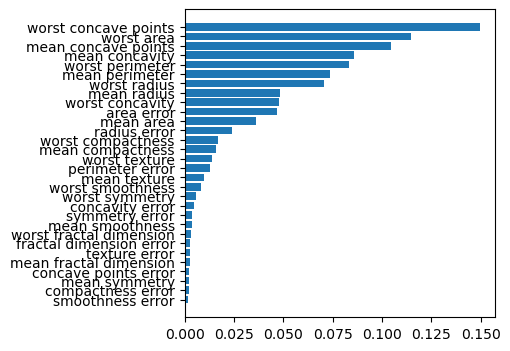

In [24]:
import matplotlib.pyplot as plt

idx = ft_impt.argsort()
fig = plt.figure(figsize=(4,4))
plt.barh(ft_name[idx], ft_impt[idx])
plt.show()

When only a small subset of features is informative, noise and variance degrade the classification task. This can be mitigated by feature selection methods (e.g., prefiltering or recursive feature elimination), or by modified ensembles such as weighted or feature-biased random forests that increase the probability of selecting informative variables. 